### Histogram EDA


In [202]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

In [203]:
data = pd.read_csv("dataset.csv")
data

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,ASUS,ASUS Pro ZWL,2023,Windows,Mainstream,Intel,Intel i7-13721,4,12,...,1920x1080,144,90,180,0,Wi-Fi 6,5.1,1.87,24,1712.99
99996,Laptop,Lenovo,Lenovo Stealth 014,2018,Windows,Ultrabook,AMD,AMD Ryzen 5 5117,2,8,...,2560x1600,90,50,65,0,Wi-Fi 6,5.1,1.37,12,1258.99
99997,Laptop,ASUS,ASUS Zen LKD,2020,Windows,Mainstream,Intel,Intel i5-12677,2,6,...,2560x1600,120,99,180,0,Wi-Fi 6,4.2,1.17,12,1686.99
99998,Laptop,ASUS,ASUS Blade DH6,2020,Windows,Mainstream,AMD,AMD Ryzen 7 4590,4,12,...,2560x1600,120,60,90,0,Wi-Fi 6,5.3,1.70,24,2164.99


In [204]:
data.columns

Index(['device_type', 'brand', 'model', 'release_year', 'os', 'form_factor',
       'cpu_brand', 'cpu_model', 'cpu_tier', 'cpu_cores', 'cpu_threads',
       'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_brand', 'gpu_model', 'gpu_tier',
       'vram_gb', 'ram_gb', 'storage_type', 'storage_gb',
       'storage_drive_count', 'display_type', 'display_size_in', 'resolution',
       'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'wifi',
       'bluetooth', 'weight_kg', 'warranty_months', 'price'],
      dtype='object')

Scale and clean data, calculate general scores and display it on radar chart

In [205]:
# Label encode storage type
storage_type_map = {
    "HDD": 0,
    "Hybrid": 1,
    "SSD": 2,
    "NVMe": 3
}
data["storage_type_enc"] = data["storage_type"].map(storage_type_map)

In [206]:
cpu_num_features = ["cpu_tier", "cpu_cores", "cpu_threads", "cpu_base_ghz", "cpu_boost_ghz"]
gpu_num_features = ["gpu_tier", "vram_gb"]
ram_features = ["ram_gb"]
storage = ["storage_type_enc", "storage_gb", "storage_drive_count"]
cat_features = ["device_type", "cpu_brand", "form_factor"]




In [207]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= (Q1 - 1.5 * IQR)) & (data[column] <= (Q3 + 1.5 * IQR))]

In [208]:
# IQR outliers detection
def IQR_detect(data):
    Q1 = data.select_dtypes(include=['float64', 'int64']).quantile(0.25) # Select only numerical columns for IQR calculation
    Q3 = data.select_dtypes(include=['float64', 'int64']).quantile(0.75)
    IQR = Q3 - Q1

    # Use the same selection of numerical columns when comparing with the IQR
    numerical_df = data.select_dtypes(include=['float64', 'int64'])
    outliers = ((numerical_df < (Q1 - 1.5 * IQR)) | (numerical_df > (Q3 + 1.5 * IQR))).sum()

    print(f"Outliers detected based on IQR method:\n{outliers}")
IQR_detect(data)

Outliers detected based on IQR method:
release_year               0
cpu_tier                   0
cpu_cores                200
cpu_threads             3551
cpu_base_ghz            1978
cpu_boost_ghz              0
gpu_tier                   0
vram_gb                 3328
ram_gb                    60
storage_gb             14811
storage_drive_count     4041
display_size_in            0
refresh_hz              2913
battery_wh                 0
charger_watts           3039
psu_watts                  0
bluetooth               5939
weight_kg               1031
warranty_months         5007
price                    976
storage_type_enc           0
dtype: int64


In [209]:
filtered_data = data
for cpu_feat in cpu_num_features:
    filtered_data = remove_outliers(filtered_data, cpu_feat)

for gpu_feat in gpu_num_features:
    filtered_data = remove_outliers(filtered_data, gpu_feat)

for ram_feat in ram_features:
    filtered_data = remove_outliers(filtered_data, ram_feat)

for storage_feat in storage:
    filtered_data = remove_outliers(filtered_data, storage_feat)

filtered_data = remove_outliers(filtered_data, "cpu_cores")


len(filtered_data)

76410

In [210]:
IQR_detect(filtered_data)

Outliers detected based on IQR method:
release_year              0
cpu_tier                  0
cpu_cores                 0
cpu_threads               0
cpu_base_ghz              0
cpu_boost_ghz             0
gpu_tier                  0
vram_gb                   0
ram_gb                    0
storage_gb                0
storage_drive_count       0
display_size_in           0
refresh_hz             2220
battery_wh                0
charger_watts          2436
psu_watts                 0
bluetooth              4573
weight_kg               735
warranty_months        3837
price                   617
storage_type_enc          0
dtype: int64


In [211]:
## Scale data
scaler = MinMaxScaler()
num_features = cpu_num_features + gpu_num_features + ram_features + storage
scaled = scaler.fit_transform(filtered_data[num_features])
scaled = pd.DataFrame(scaled, columns=num_features)

In [212]:
scaled["cpu_score"] = scaled["cpu_cores"] + scaled["cpu_threads"] 

In [213]:
# Calculate score
# CPU score = mean of CPU numeric features
scaled["cpu_score"] = scaled[cpu_num_features].mean(axis=1)

# GPU score = mean of GPU numeric features
scaled["gpu_score"] = scaled[gpu_num_features].mean(axis=1)

# RAM score = mean of RAM features
scaled["ram_score"] = scaled[ram_features].mean(axis=1)

# Storage score = mean of storage features
scaled["storage_score"] = scaled[storage].mean(axis=1)

In [214]:
scaled

,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_type_enc,storage_gb,storage_drive_count,cpu_score,gpu_score,ram_score,storage_score
0,0.50,0.500,0.555556,0.666667,0.666667,0.2,0.500000,0.076923,1.000000,1.000000,0.0,0.577778,0.350000,0.076923,0.666667
1,0.75,0.500,0.555556,0.500000,0.533333,0.6,0.833333,0.538462,1.000000,0.333333,0.0,0.567778,0.716667,0.538462,0.444444
2,0.25,0.250,0.333333,0.500000,0.533333,0.0,0.333333,0.000000,1.000000,0.333333,0.5,0.373333,0.166667,0.000000,0.611111
3,0.25,0.125,0.222222,0.500000,0.533333,0.2,0.500000,0.076923,0.000000,0.333333,0.5,0.326111,0.350000,0.076923,0.277778
4,1.00,0.750,0.777778,0.666667,0.733333,0.8,1.000000,0.846154,1.000000,0.000000,0.0,0.785556,0.900000,0.846154,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76405,0.50,0.250,0.333333,0.333333,0.266667,0.4,0.666667,0.230769,1.000000,0.333333,0.0,0.336667,0.533333,0.230769,0.444444
76406,0.50,0.500,0.555556,0.666667,0.666667,0.2,0.500000,0.076923,0.333333,1.000000,1.0,0.577778,0.350000,0.076923,0.777778
76407,0.25,0.250,0.333333,0.166667,0.266667,0.0,0.333333,0.000000,0.000000,1.000000,0.0,0.253333,0.166667,0.000000,0.333333
76408,0.25,0.125,0.166667,0.166667,0.266667,0.2,0.500000,0.076923,1.000000,1.000000,0.0,0.195000,0.350000,0.076923,0.666667


In [215]:
## Concat with label for hue
processed_data = pd.concat([scaled, filtered_data[cat_features].reset_index()], axis=1)
processed_data

,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_type_enc,storage_gb,storage_drive_count,cpu_score,gpu_score,ram_score,storage_score,index,device_type,cpu_brand,form_factor
0,0.50,0.500,0.555556,0.666667,0.666667,0.2,0.500000,0.076923,1.000000,1.000000,0.0,0.577778,0.350000,0.076923,0.666667,0,Desktop,Intel,ATX
1,0.75,0.500,0.555556,0.500000,0.533333,0.6,0.833333,0.538462,1.000000,0.333333,0.0,0.567778,0.716667,0.538462,0.444444,1,Laptop,Intel,Mainstream
2,0.25,0.250,0.333333,0.500000,0.533333,0.0,0.333333,0.000000,1.000000,0.333333,0.5,0.373333,0.166667,0.000000,0.611111,2,Desktop,AMD,SFF
3,0.25,0.125,0.222222,0.500000,0.533333,0.2,0.500000,0.076923,0.000000,0.333333,0.5,0.326111,0.350000,0.076923,0.277778,3,Desktop,AMD,ATX
4,1.00,0.750,0.777778,0.666667,0.733333,0.8,1.000000,0.846154,1.000000,0.000000,0.0,0.785556,0.900000,0.846154,0.333333,4,Laptop,AMD,Gaming
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76405,0.50,0.250,0.333333,0.333333,0.266667,0.4,0.666667,0.230769,1.000000,0.333333,0.0,0.336667,0.533333,0.230769,0.444444,99993,Laptop,AMD,Gaming
76406,0.50,0.500,0.555556,0.666667,0.666667,0.2,0.500000,0.076923,0.333333,1.000000,1.0,0.577778,0.350000,0.076923,0.777778,99994,Desktop,Intel,Mini-ITX
76407,0.25,0.250,0.333333,0.166667,0.266667,0.0,0.333333,0.000000,0.000000,1.000000,0.0,0.253333,0.166667,0.000000,0.333333,99996,Laptop,AMD,Ultrabook
76408,0.25,0.125,0.166667,0.166667,0.266667,0.2,0.500000,0.076923,1.000000,1.000000,0.0,0.195000,0.350000,0.076923,0.666667,99997,Laptop,Intel,Mainstream


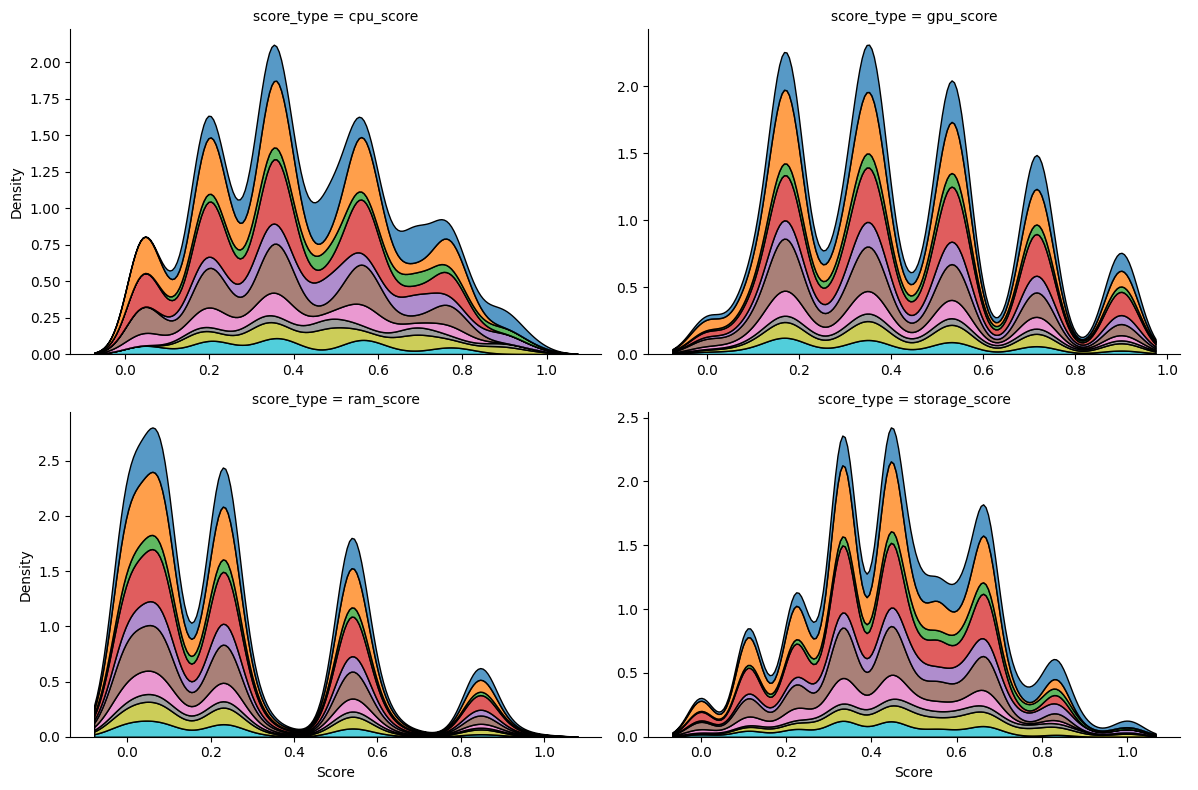

In [234]:
score_cols = ["cpu_score", "gpu_score", "ram_score", "storage_score"]

# Make data long-form for FacetGrid
long_df = processed_data.melt(
    id_vars="form_factor",          # grouping / hue variable
    value_vars=score_cols,          # the 4 score columns
    var_name="score_type",          # new column: which score?
    value_name="score"              # new column: the score value
)

# Facet by score_type
g = sns.FacetGrid(
    long_df,
    col="score_type",
    col_wrap=2,          # 2x2 layout
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.kdeplot,
    x="score",
    hue="form_factor",
    multiple="stack",
    fill=True
)

g.add_legend()
g.set_axis_labels("Score", "Density")
g.fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

<Axes: xlabel='cpu_score', ylabel='Density'>

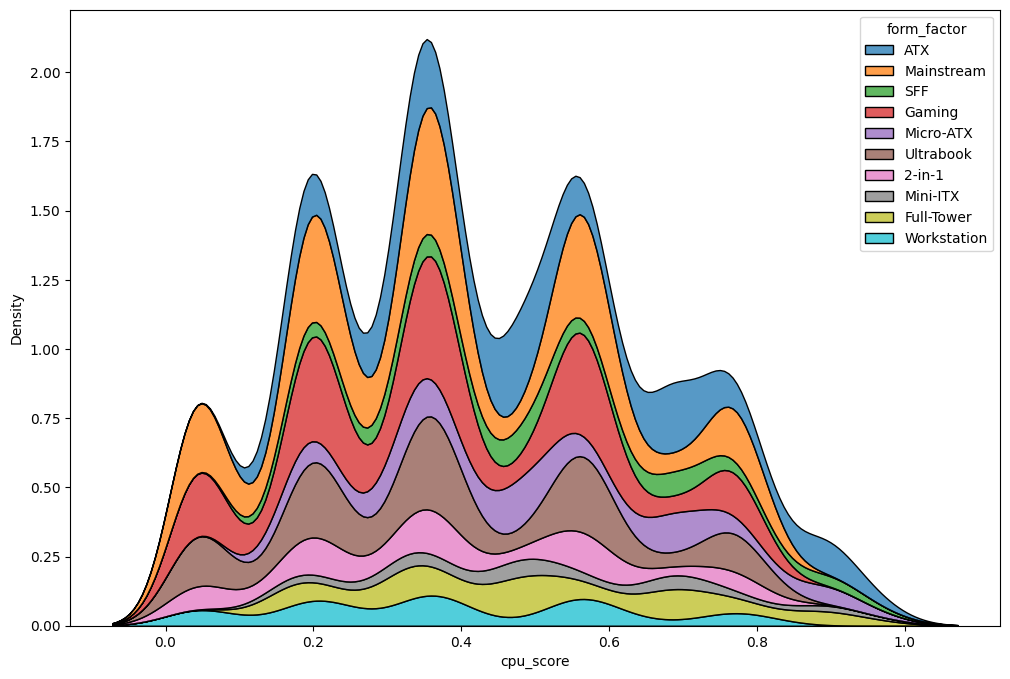

In [235]:
plt.figure(figsize=(12, 8)) # Width=10 inches, Height=6 inches 
sns.kdeplot(processed_data, x="cpu_score", hue="form_factor", multiple="stack")

/tmp/ipykernel_37215/1914682599.py:2: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(processed_data[1030:1050], x="cpu_score", y="gpu_score", alpha=0.5, hue=cat_features[1], multiple="stack")


<Axes: xlabel='cpu_score', ylabel='gpu_score'>

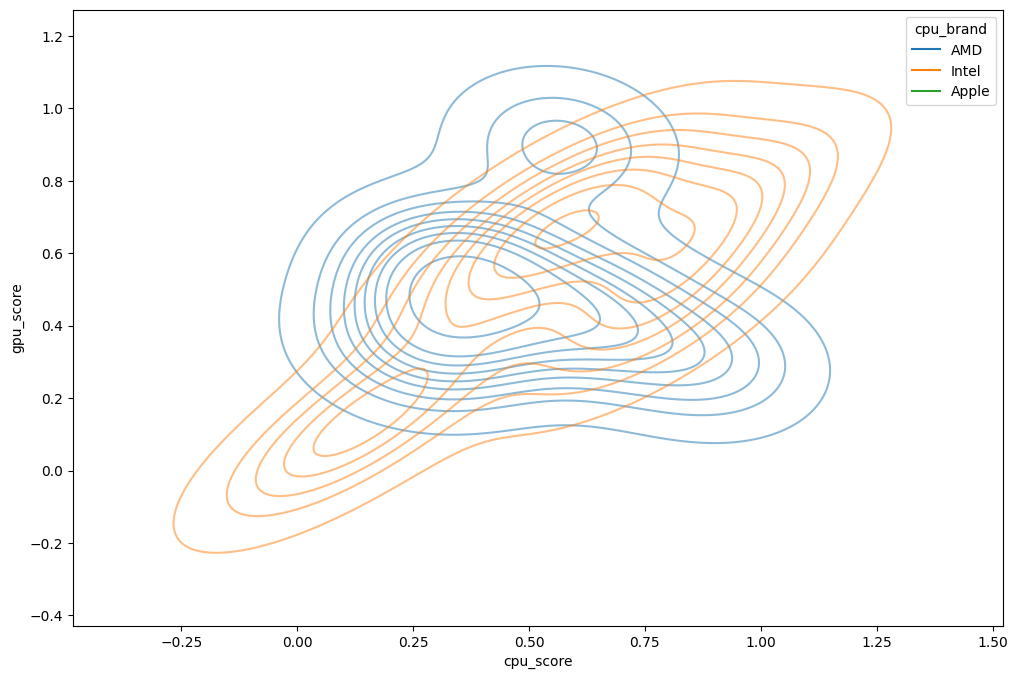

In [264]:
plt.figure(figsize=(12, 8)) # Width=10 inches, Height=6 inches 
sns.kdeplot(processed_data[1030:1050], x="cpu_score", y="gpu_score", alpha=0.5, hue=cat_features[1], multiple="stack")

Should show 1d kde plot on each axis, a slide to change the price and release year.